<a href="https://colab.research.google.com/github/AnuragTiwari-hub/AIML/blob/main/AIML_14_(feature_scalling).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wine-clustering.csv to wine-clustering.csv


Final Data with Scaling:

     Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      14.23        1.71  2.43          15.6        127           2.80   
1      13.20        1.78  2.14          11.2        100           2.65   
2      13.16        2.36  2.67          18.6        101           2.80   
3      14.37        1.95  2.50          16.8        113           3.85   
4      13.24        2.59  2.87          21.0        118           2.80   
..       ...         ...   ...           ...        ...            ...   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5         96           2.05   

     Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0   

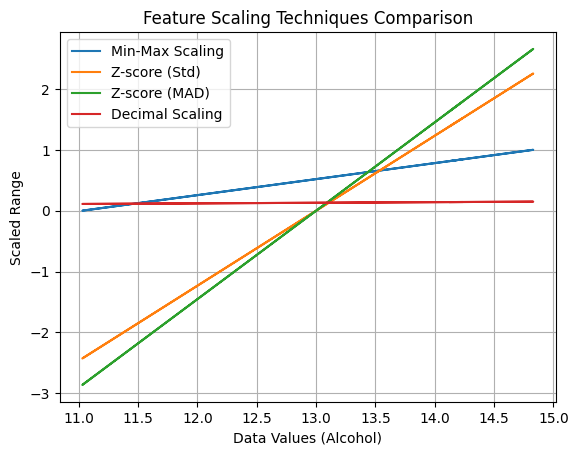


Split 1: Train=80.0%, Validation=10.0%, Test=10.0%

Train Data:
      Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      13.64        3.10  2.56          15.2        116           2.70   
1      14.21        4.04  2.44          18.9        111           2.85   
2      12.93        2.81  2.70          21.0         96           1.54   
3      13.73        1.50  2.70          22.5        101           3.00   
4      12.37        1.17  1.92          19.6         78           2.11   
..       ...         ...   ...           ...        ...            ...   
137    13.11        1.90  2.75          25.5        116           2.20   
138    12.88        2.99  2.40          20.0        104           1.30   
139    13.83        1.57  2.62          20.0        115           2.95   
140    13.49        1.66  2.24          24.0         87           1.88   
141    13.17        5.19  2.32          22.0         93           1.74   

     Flavanoids  Nonflavanoid_Phenols  Proant

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: Create Dataset
# -------------------------------
df = pd.read_csv('wine-clustering.csv')

# Assuming 'Alcohol' is a numerical column in wine-clustering.csv for demonstration
# If a different column is intended for scaling, please specify.
scaling_column = 'Alcohol'

# -------------------------------
# STEP 2: Feature Scaling
# -------------------------------

# Min-Max Scaling
df['MinMax'] = (df[scaling_column] - df[scaling_column].min()) / (df[scaling_column].max() - df[scaling_column].min())

# Z-score (Standard Deviation)
df['Z_std'] = (df[scaling_column] - df[scaling_column].mean()) / df[scaling_column].std()

# Z-score (MAD)
mad = (df[scaling_column] - df[scaling_column].mean()).abs().mean()
df['Z_MAD'] = (df[scaling_column] - df[scaling_column].mean()) / mad

# Decimal Scaling
j = len(str(int(df[scaling_column].abs().max())))
df['Decimal'] = df[scaling_column] / (10 ** j)

print("Final Data with Scaling:\n")
print(df)

# -------------------------------
# STEP 3: Plot Graph
# -------------------------------
plt.figure()

plt.plot(df[scaling_column], df['MinMax'], label='Min-Max Scaling')
plt.plot(df[scaling_column], df['Z_std'], label='Z-score (Std)')
plt.plot(df[scaling_column], df['Z_MAD'], label='Z-score (MAD)')
plt.plot(df[scaling_column], df['Decimal'], label='Decimal Scaling')

plt.xlabel(f"Data Values ({scaling_column})")   # X-axis
plt.ylabel("Scaled Range")          # Y-axis
plt.title("Feature Scaling Techniques Comparison")

plt.legend()
plt.grid()

plt.show()

# -------------------------------
# STEP 4: Dataset Splitting
# -------------------------------

def split_data(data, train_ratio, val_ratio, test_ratio):
    shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(data)

    # Using round to avoid empty splits
    train_end = round(train_ratio * n)
    val_end = train_end + round(val_ratio * n)

    train = shuffled[:train_end]
    val = shuffled[train_end:val_end]
    test = shuffled[val_end:]

    return train, val, test

# -------------------------------
# STEP 5: Apply Different Splits
# -------------------------------

splits = [
    (0.8, 0.1, 0.1),
    (0.7, 0.2, 0.1),
    (0.7, 0.1, 0.2)
]

for i, (tr, va, te) in enumerate(splits, 1):
    train, val, test = split_data(df, tr, va, te)

    print(f"\nSplit {i}: Train={tr*100}%, Validation={va*100}%, Test={te*100}%")

    print("\nTrain Data:\n", train)
    print("\nValidation Data:\n", val)
    print("\nTest Data:\n", test)
